In [47]:
import pandas as pd 
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20637,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20638,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20639,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20640,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [48]:
print(data.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [49]:
duplicates = data.duplicated().sum()
print(duplicates)

2


In [50]:
data = data.drop_duplicates()

In [51]:
data['total_bedrooms'] = data['total_bedrooms'].fillna(
    data['total_bedrooms'].mean())

In [52]:
Q1 = data['total_rooms'].quantile(0.25)
Q3 = data['total_rooms'].quantile(0.75)
IQR = Q3 - Q1

outliers = data[(data['total_rooms'] < Q1 - 1.5 * IQR) | 
                (data['total_rooms'] > Q3 + 1.5 * IQR)]

print("Nombre d'outliers :", len(outliers))


Nombre d'outliers : 1287


<Axes: xlabel='total_rooms'>

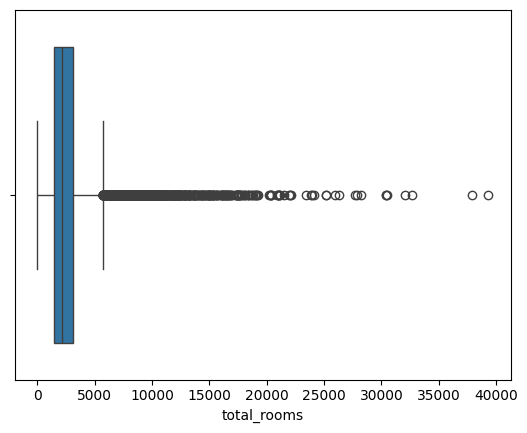

In [53]:
import seaborn as sns
sns.boxplot(x=data['total_rooms'])

In [54]:
import numpy as np

mean = np.mean(data["total_rooms"])
std = np.std(data["total_rooms"])

data["Zscore"] = (data["total_rooms"] - mean) / std

outliers = data[np.abs(data["Zscore"]) > 3]
print(outliers)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
283      -122.16     37.79                22.0      12842.0          2048.0   
570      -122.24     37.72                 5.0      18634.0          2885.0   
576      -122.06     37.77                12.0      14316.0          2045.0   
780      -122.10     37.63                18.0       9963.0          2031.0   
864      -122.01     37.57                14.0      16199.0          2993.0   
...          ...       ...                 ...          ...             ...   
20453    -118.90     34.26                 5.0      25187.0          3521.0   
20531    -121.78     38.55                12.0      10509.0          2186.0   
20532    -121.76     38.57                11.0      15018.0          3008.0   
20565    -121.75     38.67                 9.0      12139.0          2640.0   
20631    -121.39     39.12                28.0      10035.0          1856.0   

       population  households  median_income  media

In [55]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data_clean = data[(data["total_rooms"] >= lower) & (data["total_rooms"] <= upper)]

In [63]:
import numpy as np

data["total_rooms"] = np.where(data["total_rooms"] > upper, upper, data["total_rooms"])
data["total_rooms"] = np.where(data["total_rooms"] < lower, lower, data["total_rooms"])
print(data["total_rooms"].head(390))

0       880.000
1      5698.375
2      1467.000
3      1274.000
4      1627.000
         ...   
385    1283.000
386    1604.000
387    2248.000
388    2263.000
389    1571.000
Name: total_rooms, Length: 390, dtype: float64


In [57]:
import numpy as np

data["total_log"] = np.log(data["total_rooms"])
print(data["total_rooms"])
           

0         880.000
1        5698.375
2        1467.000
3        1274.000
4        1627.000
           ...   
20637    1665.000
20638     697.000
20639    2254.000
20640    1860.000
20641    2785.000
Name: total_rooms, Length: 20640, dtype: float64


In [58]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
data["total_scaled"] = scaler.fit_transform(data[["total_rooms"]])
print(data["total_scaled"])

0       -0.733422
1        2.100500
2       -0.388178
3       -0.501691
4       -0.294074
           ...   
20637   -0.271725
20638   -0.841053
20639    0.074695
20640   -0.157036
20641    0.387002
Name: total_scaled, Length: 20640, dtype: float64


In [59]:
print(data.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
Zscore                0
total_log             0
total_scaled          0
dtype: int64


# Visualisation des Données Immobilières
**Analyse complète et étude de cas sur le dataset Housing**

La visualisation des données est un processus essentiel en analyse de données. Elle permet de transformer des chiffres bruts en représentations graphiques compréhensibles, afin de détecter rapidement des tendances, des anomalies et des relations cachées entre variables. L’objectif principal de cette présentation est de vous montrer comment explorer et interpréter un dataset immobilier de manière efficace à travers différentes techniques de visualisation.


## Importance de la visualisation

Visualiser les données est crucial car les humains comprennent mieux les images que les chiffres seuls. En représentant graphiquement les informations, il est possible de détecter des patterns complexes, d’identifier les valeurs aberrantes et de communiquer efficacement les résultats à un public non technique. Une bonne visualisation permet aussi de guider la prise de décision et de prioriser les actions basées sur des insights précis.


## Types de données

Le dataset étudié contient différents types de données qui nécessitent des approches de visualisation adaptées. Les variables numériques comme `median_income`, `median_house_value` et `total_rooms` peuvent être représentées à l’aide d’histogrammes, de scatter plots et de boxplots. Les variables catégorielles, telles que `ocean_proximity`, se visualisent mieux avec des diagrammes à barres ou des camemberts. Les coordonnées géographiques `longitude` et `latitude` permettent la création de cartes pour visualiser la répartition spatiale des logements.


## Objectifs spécifiques

Dans cette présentation, nous allons explorer plusieurs aspects du dataset immobilier. Nous voulons comprendre comment les revenus influencent la valeur des maisons, examiner l’impact de l’âge des logements sur leurs prix, et analyser la distribution géographique des maisons par rapport à l’océan. Chaque objectif sera illustré par des graphiques clairs et interprétables, permettant d’extraire des insights concrets et exploitables pour une meilleure compréhension des données.


## Étapes clés

Pour créer des visualisations efficaces, il est important de suivre plusieurs étapes. Tout d’abord, il faut bien comprendre les données et leur type. Ensuite, choisir le graphique approprié pour chaque type de variable. Ajouter des titres clairs, des axes étiquetés et des légendes compréhensibles. Il est également crucial d’utiliser des couleurs et tailles adaptées pour mettre en valeur les informations importantes. Enfin, il faut vérifier les anomalies et valeurs extrêmes pour éviter des interprétations erronées.


## Erreurs courantes

Lors de la visualisation des données, certaines erreurs peuvent fausser l’interprétation. Utiliser trop de couleurs ou des graphiques surchargés peut rendre l’information illisible. Choisir un type de graphique inapproprié pour le type de donnée peut induire en erreur. Ignorer les valeurs extrêmes ou anomalies peut aussi masquer des patterns importants. Il est donc essentiel de planifier la visualisation en gardant en tête la clarté et la précision des insights.


## Historique et impact

La visualisation des données a évolué depuis les graphiques papier traditionnels jusqu’aux dashboards interactifs modernes. Son impact est majeur dans le domaine de la prise de décision, que ce soit dans l’immobilier, la finance, la santé ou le marketing. Une visualisation bien conçue permet d’identifier rapidement les opportunités et risques, de comparer des variables complexes et de présenter des résultats de manière accessible même aux personnes non techniques.


## Outils Python pour la visualisation

Python offre plusieurs bibliothèques puissantes pour la visualisation des données. `Pandas` facilite la manipulation et l’exploration des données. `Matplotlib` permet de créer des graphiques simples tels que lignes, barres et histogrammes. `Seaborn` est idéal pour des visualisations statistiques avancées comme les boxplots et heatmaps. `Plotly` permet des graphiques interactifs, tandis que `GeoPandas` et `Folium` sont adaptés pour les cartes et données géographiques. Le choix de l’outil dépend du type de données et du niveau d’interactivité souhaité.


## Bonnes pratiques

Pour que la visualisation soit efficace, il est recommandé de choisir un graphique adapté à la nature de la donnée, d’ajouter des titres clairs, des axes correctement étiquetés et des légendes explicites. Il est important de choisir des couleurs cohérentes et lisibles, d’éviter la surcharge d’informations et de toujours vérifier la présence de valeurs extrêmes ou anomalies pouvant influencer l’interprétation. Ces bonnes pratiques assurent une communication claire et précise des insights extraits des données.


## Transition vers l’étude de cas

Après avoir exploré les concepts théoriques et les bonnes pratiques, nous allons appliquer ces techniques de visualisation sur un dataset immobilier réel. L’objectif est d’illustrer concrètement comment analyser les tendances des prix, identifier les relations entre revenu et valeur des maisons, examiner l’influence de l’océan et de l’âge des logements, et produire des graphiques clairs et interprétables.


## Pandas : la base pour explorer vos données

Pandas est la bibliothèque incontournable pour manipuler les datasets en Python. Elle permet de charger des fichiers CSV, Excel ou SQL directement dans des DataFrames. Chaque colonne et chaque ligne devient accessible facilement, ce qui facilite le calcul de statistiques, le filtrage de données et la préparation avant visualisation. Grâce à Pandas, on peut rapidement obtenir un aperçu des valeurs, identifier des valeurs manquantes et préparer les données pour les graphiques.


In [1]:
import pandas as pd
df = pd.read_csv("housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Matplotlib : visualisation simple mais puissante

Matplotlib est la bibliothèque la plus populaire pour créer des graphiques en Python. Elle permet de créer des histogrammes, graphiques en ligne, diagrammes à barres, scatter plots et plus encore. L’avantage est que chaque élément du graphique (titre, axes, couleur, taille) peut être personnalisé pour rendre la visualisation claire et esthétique. Matplotlib est parfait pour des graphiques statiques et précis.


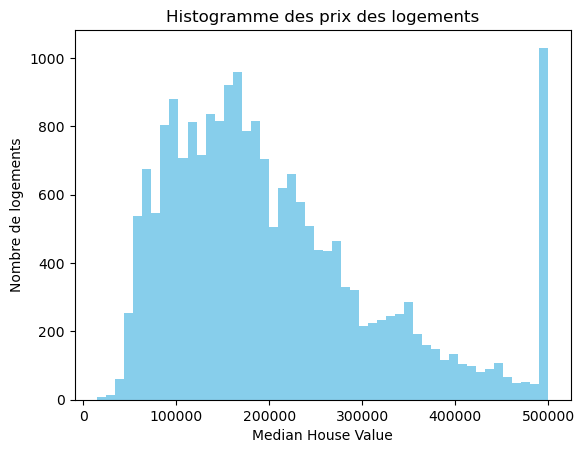

In [2]:
import matplotlib.pyplot as plt
plt.hist(df['median_house_value'], bins=50, color='skyblue')
plt.title("Histogramme des prix des logements")
plt.xlabel("Median House Value")
plt.ylabel("Nombre de logements")
plt.show()


## Seaborn : graphiques statistiques avancés

Seaborn est construit sur Matplotlib mais simplifie la création de graphiques statistiques complexes. Les boxplots, heatmaps, pairplots et violin plots sont très faciles à générer. Il permet aussi de visualiser rapidement la distribution des données et les corrélations entre plusieurs variables. Seaborn est idéal pour l’analyse exploratoire et pour détecter les patterns cachés dans le dataset.


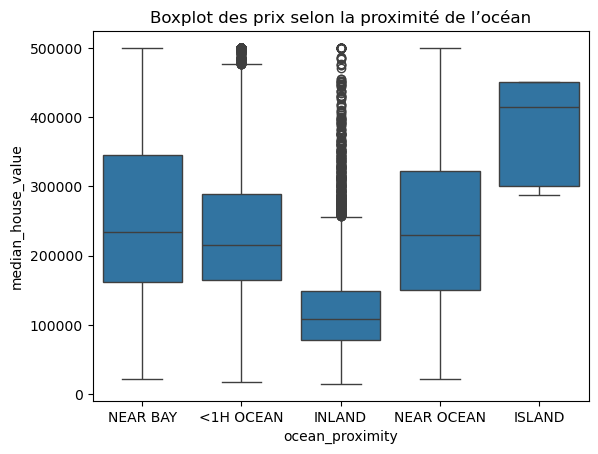

In [3]:
import seaborn as sns
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df)
plt.title("Boxplot des prix selon la proximité de l’océan")
plt.show()


## Plotly : explorer les données de manière interactive

Plotly permet de créer des graphiques dynamiques, interactifs et esthétiques. On peut zoomer, survoler les points avec la souris et filtrer des catégories en temps réel. C’est très pratique pour des dashboards ou des présentations où l’utilisateur peut explorer les données par lui-même. Les scatter plots, histogrammes et cartes interactives sont particulièrement utiles pour un dataset immobilier.


In [4]:
import plotly.express as px
fig = px.scatter(df, x='median_income', y='median_house_value', color='ocean_proximity', size='population', hover_data=['total_rooms','total_bedrooms'])
fig.show()


## GeoPandas / Folium : visualisation géographique

Ces bibliothèques permettent de représenter des données géographiques. Avec les coordonnées `longitude` et `latitude`, on peut visualiser la distribution spatiale des logements, ajouter des couleurs selon le prix ou le revenu et créer des cartes interactives pour explorer la localisation des maisons. Très utile pour l’analyse immobilière et la prise de décision basée sur la localisation.


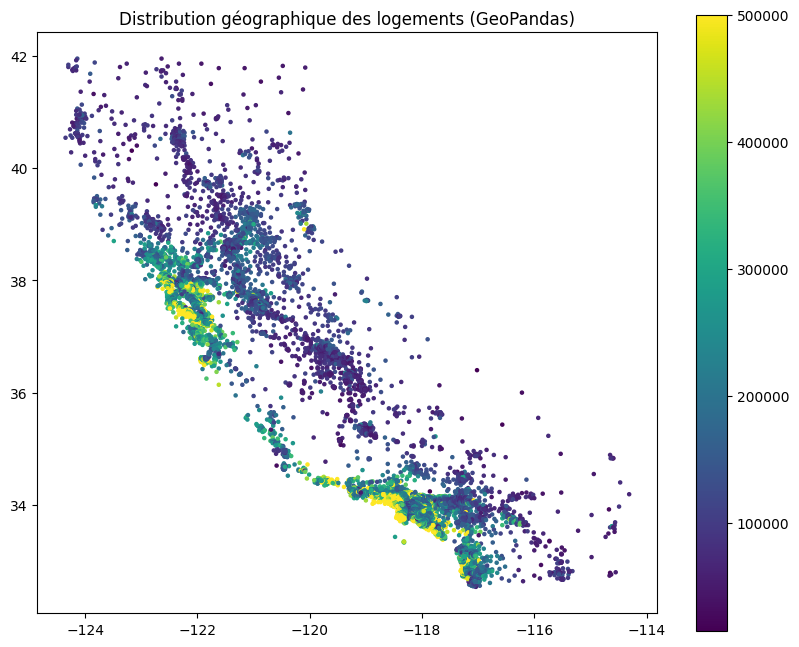

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

# Charger le dataset
df = pd.read_csv("housing.csv")

# Créer une colonne geometry avec longitude et latitude
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
geo_df = gpd.GeoDataFrame(df, geometry=geometry)

# Plot simple : couleur selon median_house_value
geo_df.plot(column='median_house_value', cmap='viridis', markersize=5, legend=True, figsize=(10,8))
plt.title("Distribution géographique des logements (GeoPandas)")
plt.show()
